# Neural Network Training for Spirob (13-Joint Configuration) - Optimized

Fast training pipeline with 13 joint angles.

In [1]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import json
import os
from datetime import datetime

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ==================== CONFIGURATION ====================

# Data Configuration
FILE_PATHS = [
    "runs/2026-02-05_14-46-22/merged_smoothed.csv",
    "runs/2026-02-06_14-14-43/merged_smoothed.csv",
    "runs/2026-02-09_12-34-53/merged_smoothed.csv",
    "runs/2026-02-10_12-14-57/merged_smoothed.csv",
    "runs/2026-02-11_17-22-11/merged.csv",
    "runs/2026-02-16_12-20-17/merged_smoothed.csv",
    "runs/2026-02-16_15-19-31/merged_smoothed.csv",
    "runs/2026-02-16_16-58-18/merged_smoothed.csv",
    "runs/2026-02-19_10-14-37/merged_smoothed.csv"
]

# Feature Selection (Welche Features sollen ins Training?)
# Options:
#   ["magX", "magY", "magZ"]                              # Nur Magnetometer Achsen
#   ["magX", "magY", "magZ", "accX", "accY", "accZ"]     # Mag + Acc Achsen (alle)
#   ["magX", "magY", "magZ", "accMag"]                   # Mag Achsen + Acc Magnitude (orientierungsunabhängig!)
#   ["magX", "magY", "magZ", "magMag", "accMag"]         # Nur Magnitudes
FEATURE_SELECTION = ["magX", "magY","magZ"]

# Sensor selection (set to a list of sensor IDs or None for all)
# Example: SENSOR_ID_FILTER = [0, 1, 2]  # only these sensors
# Example: SENSOR_ID_FILTER = None       # use all sensors
SENSOR_ID_FILTER = None

# Model Selection
MODEL_TYPE = "LSTM"  # "FeedForward" or "LSTM"

# Training Configuration
VAL_SIZE = 0.2   # Validation set size
TEST_SIZE = 0.2  # Test set size
RANDOM_SEED = 41
WINDOW_SIZE = 20  # For LSTM 20
BATCH_SIZE = 32 #32
HIDDEN_SIZE = 64
NUM_LSTM_LAYERS = 2
EPOCHS = 150
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.3  # 🔧 
WEIGHT_DECAY = 0.0001  # 🆕 L2-Regularisierung (verhindert zu große Gewichte)
EARLY_STOPPING_PATIENCE = 40  # 🆕 Early Stopping (stoppt wenn kein Fortschritt)

print(f"📊 Dataset: {len(FILE_PATHS)} files")
print(f"🤖 Model: {MODEL_TYPE}")
print(f"⚙️  Regularisierung: Dropout={DROPOUT_RATE}, L2={WEIGHT_DECAY}, EarlyStop={EARLY_STOPPING_PATIENCE}")

# Detect THETA columns from CSV (auto-detect number of joints)
import polars as pl
df_sample = pl.read_csv(FILE_PATHS[0], n_rows=1)
THETA_COLS = [c for c in df_sample.columns if c.startswith("theta_")]
print(f"🎯 Output: {len(THETA_COLS)} joint angles detected: {THETA_COLS}")
print(f"🔧 Feature Selection: {FEATURE_SELECTION}")

📊 Dataset: 9 files
🤖 Model: LSTM
⚙️  Regularisierung: Dropout=0.3, L2=0.0001, EarlyStop=40
🎯 Output: 13 joint angles detected: ['theta_1', 'theta_2', 'theta_3', 'theta_4', 'theta_5', 'theta_6', 'theta_7', 'theta_8', 'theta_9', 'theta_10', 'theta_11', 'theta_12', 'theta_13']
🔧 Feature Selection: ['magX', 'magY', 'magZ']


In [3]:
# ==================== LOAD AND PIVOT DATA ====================

def load_and_pivot_run(path, expected_sensors=None, sensor_filter=None):
    print(f"Loading {path}...")
    df = pl.read_csv(path)

    # Ensure consistent dtypes across files
    if "sensor_id" in df.columns:
        df = df.with_columns(pl.col("sensor_id").cast(pl.Int64, strict=False))

    # Apply sensor filter if provided
    if sensor_filter is not None:
        df = df.filter(pl.col("sensor_id").is_in(sensor_filter))

    # Lade ALLE verfügbaren Sensor-Spalten
    ALL_SENSOR_COLS = ["magX", "magY", "magZ", "accX", "accY", "accZ"]
    available_sensor_cols = [c for c in ALL_SENSOR_COLS if c in df.columns]
    
    numeric_cols = available_sensor_cols + [c for c in THETA_COLS if c in df.columns]
    if numeric_cols:
        df = df.with_columns([
            pl.col(c).cast(pl.Float64, strict=False).alias(c) for c in numeric_cols
        ])

    sensor_ids = sorted(df["sensor_id"].unique().to_list())
    print(f"  Found sensors: {sensor_ids}")
    num_sensors = len(sensor_ids)

    # Create sample_id for pivoting
    sample_ids = np.arange(len(df)) // num_sensors
    df = df.with_columns(pl.Series("sample_id", sample_ids))

    # Pivot sensor data - ALLE verfügbaren Spalten
    pivoted = df.pivot(
        values=available_sensor_cols,
        index="sample_id",
        on="sensor_id",
        aggregate_function="mean"
    ).sort("sample_id")

    # Get targets
    targets = df.group_by("sample_id", maintain_order=True).agg(
        [pl.col(c).mean() for c in THETA_COLS]
    ).sort("sample_id")

    # Join
    full_df = pivoted.join(targets, on="sample_id", how="inner")

    # Ensure all expected sensors have columns
    if expected_sensors is not None:
        for sensor_id in expected_sensors:
            for col_base in available_sensor_cols:
                col_name = f"{col_base}_{sensor_id}"
                if col_name not in full_df.columns:
                    full_df = full_df.with_columns(pl.lit(0.0).alias(col_name))

        # Reorder columns
        sensor_cols = []
        for sensor_id in expected_sensors:
            for col_base in available_sensor_cols:
                sensor_cols.append(f"{col_base}_{sensor_id}")

        ordered_cols = [c for c in sensor_cols + THETA_COLS if c in full_df.columns]
        full_df = full_df.select(ordered_cols)

    # Drop NaN rows
    full_df = full_df.drop_nulls()

    print(f"  Shape: {full_df.shape}")
    return full_df

# Get all unique sensor IDs
all_sensor_ids = set()
for p in FILE_PATHS:
    df_temp = pl.read_csv(p)
    if "sensor_id" in df_temp.columns:
        df_temp = df_temp.with_columns(pl.col("sensor_id").cast(pl.Int64, strict=False))
    if SENSOR_ID_FILTER is not None:
        df_temp = df_temp.filter(pl.col("sensor_id").is_in(SENSOR_ID_FILTER))
    all_sensor_ids.update(df_temp["sensor_id"].unique().to_list())

expected_sensors = sorted(all_sensor_ids)
print(f"Expected sensors: {expected_sensors}")
print("-" * 30)

# Load all runs
data_frames = []
for i, p in enumerate(FILE_PATHS):
    df_run = load_and_pivot_run(p, expected_sensors=expected_sensors, sensor_filter=SENSOR_ID_FILTER)
    df_run = df_run.with_columns(pl.lit(i).alias("run_id"))
    data_frames.append(df_run)

master_df = pl.concat(data_frames)
print(f"Total dataset shape: {master_df.shape}")

Expected sensors: [0, 1, 2, 3, 4, 5]
------------------------------
Loading runs/2026-02-05_14-46-22/merged_smoothed.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (2913, 49)
Loading runs/2026-02-06_14-14-43/merged_smoothed.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (4152, 49)
Loading runs/2026-02-09_12-34-53/merged_smoothed.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (4998, 49)
Loading runs/2026-02-10_12-14-57/merged_smoothed.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (6324, 49)
Loading runs/2026-02-11_17-22-11/merged.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (2897, 49)
Loading runs/2026-02-16_12-20-17/merged_smoothed.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (2838, 49)
Loading runs/2026-02-16_15-19-31/merged_smoothed.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (2274, 49)
Loading runs/2026-02-16_16-58-18/merged_smoothed.csv...
  Found sensors: [0, 1, 2, 3, 4, 5]
  Shape: (1987, 49)
Loading runs/2026-02-19_10-14-37/merged_smoot

📊 Visualizing dataset shape: (33210, 50)


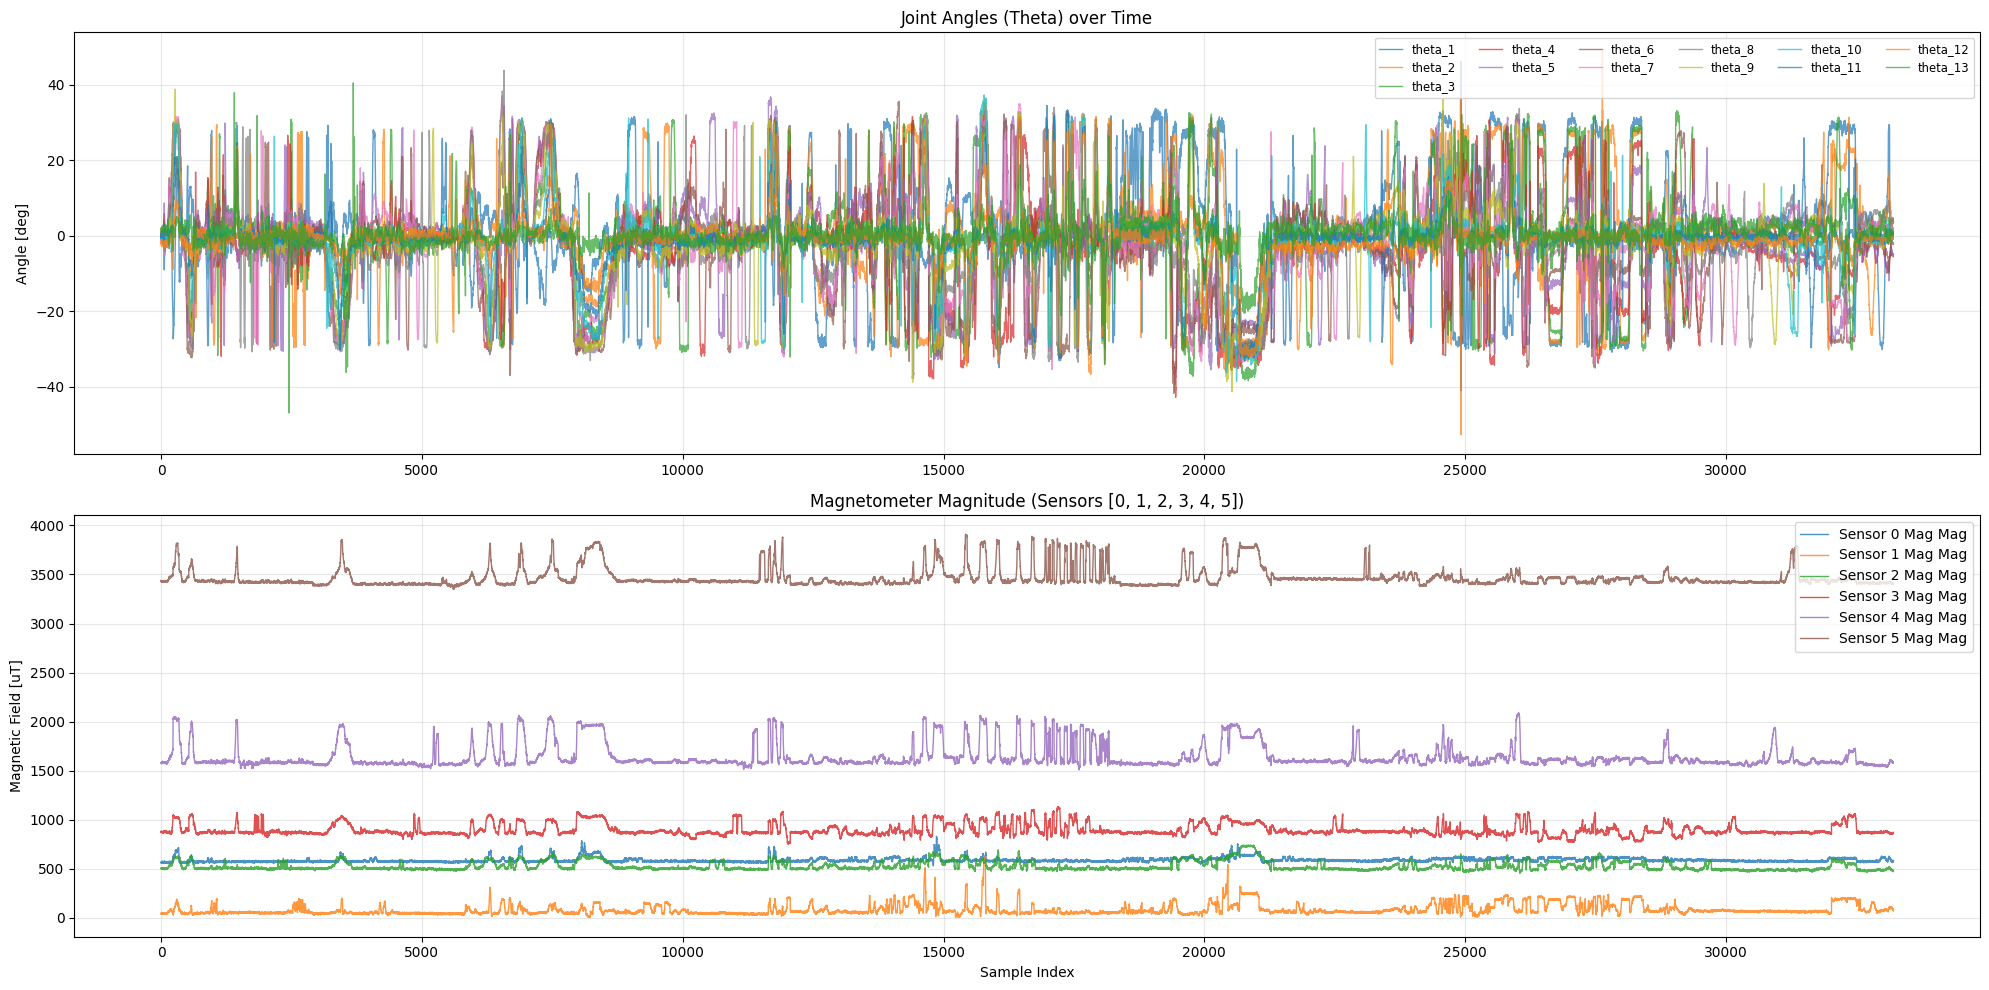

In [4]:
# ==================== DATASET VISUALIZATION ====================
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
# Convert to pandas for easier plotting (if not already done)
# master_df comes from the previous cells
df_viz = master_df.to_pandas()
print(f"📊 Visualizing dataset shape: {df_viz.shape}")
plt.figure(figsize=(20, 10))
# Plot 1: Joint Angles (Theta) over Time
plt.subplot(2, 1, 1)
# Detect theta columns again to be safe
theta_cols_viz = [c for c in df_viz.columns if c.startswith("theta_")]
for col in theta_cols_viz:
    plt.plot(df_viz[col], label=col, alpha=0.7, linewidth=1)
plt.title("Joint Angles (Theta) over Time")
plt.ylabel("Angle [deg]")
plt.legend(loc='upper right', ncol=6, fontsize='small')
plt.grid(True, alpha=0.3)
# Plot 2: Magnetometer Magnitude (First 6 sensors)
plt.subplot(2, 1, 2)
# Determine sensors to plot (first 6 found in columns)
sensor_cols_mag = [c for c in df_viz.columns if c.startswith("magX_")]
sensor_ids_viz = sorted(list(set([int(c.split('_')[1]) for c in sensor_cols_mag])))[:6]
for sid in sensor_ids_viz:
    if f"magMag_{sid}" in df_viz.columns:
        mag_mag = df_viz[f"magMag_{sid}"]
    else:
        mag_mag = np.sqrt(df_viz[f"magX_{sid}"]**2 + df_viz[f"magY_{sid}"]**2 + df_viz[f"magZ_{sid}"]**2)
        
    plt.plot(mag_mag, label=f"Sensor {sid} Mag Mag", alpha=0.8, linewidth=1)
plt.title(f"Magnetometer Magnitude (Sensors {sensor_ids_viz})")
plt.ylabel("Magnetic Field [uT]")
plt.xlabel("Sample Index")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ==================== FEATURE ENGINEERING ====================

import pandas as pd
import numpy as np

df_pandas = master_df.to_pandas()

# Identifiziere alle Sensoren aus den Spalten
all_cols = [c for c in df_pandas.columns if c not in THETA_COLS and c not in ("t_pc_ns", "run_id")]
sensor_ids = sorted(set([int(c.split('_')[-1]) for c in all_cols if '_' in c]))

print(f"🔧 Feature Engineering für {len(sensor_ids)} Sensoren...")

# SCHRITT 1️⃣: Berechne ALLE Magnitudes (falls Komponenten existieren)
for sid in sensor_ids:
    # Magnetometer Magnitude
    if all(f"mag{axis}_{sid}" in df_pandas.columns for axis in ["X", "Y", "Z"]):
        df_pandas[f"magMag_{sid}"] = np.sqrt(
            df_pandas[f"magX_{sid}"]**2 +
            df_pandas[f"magY_{sid}"]**2 +
            df_pandas[f"magZ_{sid}"]**2
        )

    # Accelerometer Magnitude
    if all(f"acc{axis}_{sid}" in df_pandas.columns for axis in ["X", "Y", "Z"]):
        df_pandas[f"accMag_{sid}"] = np.sqrt(
            df_pandas[f"accX_{sid}"]**2 +
            df_pandas[f"accY_{sid}"]**2 +
            df_pandas[f"accZ_{sid}"]**2
        )


# SCHRITT 2️⃣: Wähle Features basierend auf FEATURE_SELECTION
feature_cols = []
for sid in sensor_ids:
    for feature_name in FEATURE_SELECTION:
        col_name = f"{feature_name}_{sid}"
        if col_name in df_pandas.columns:
            feature_cols.append(col_name)
        else:
            print(f"   ⚠️  Warnung: {col_name} nicht gefunden (Feature wird übersprungen)")

# Duplikate entfernen (falls vorhanden)
feature_cols = list(dict.fromkeys(feature_cols))

print(f"\n📊 Feature Auswahl:")
print(f"   Sensoren: {sensor_ids}")
print(f"   Gewählte Features: {FEATURE_SELECTION}")
print(f"   Total Features: {len(feature_cols)} = {len(sensor_ids)} Sensoren × {len(FEATURE_SELECTION)} Features")
print(f"   Feature-Spalten: {feature_cols[:10]}..." if len(feature_cols) > 10 else f"   Feature-Spalten: {feature_cols}")

X_raw = df_pandas[feature_cols].values
Y_raw = df_pandas[THETA_COLS].values
run_ids_raw = df_pandas["run_id"].values  # 🆕 Run-Zuordnung tracken

print(f"\n✅ Daten extrahiert:")
print(f"   X shape: {X_raw.shape}")
print(f"   Y shape: {Y_raw.shape}")
print(f"   Runs: {np.unique(run_ids_raw)}")

# ==================== PHYSICAL ANGLE LIMIT CLEANING ====================

PHYSICAL_ANGLE_LIMIT = 35.0  # ±35° für alle Gelenke

# Berechne maximale Abweichung über alle Theta-Spalten
max_angles = np.max(np.abs(Y_raw), axis=1)
invalid_angle_mask = max_angles > PHYSICAL_ANGLE_LIMIT

# Finde betroffene Samples
invalid_indices = np.where(invalid_angle_mask)[0]
valid_physical_mask = ~invalid_angle_mask

# Statistiken
n_invalid = np.sum(invalid_angle_mask)
percent_invalid = 100 * n_invalid / len(Y_raw)

print(f"\n🔬 Physical Angle Limit Cleaning (±{PHYSICAL_ANGLE_LIMIT}°):")
print(f"   Ungültige Samples: {n_invalid} ({percent_invalid:.2f}%)")

if n_invalid > 0:
    for theta_idx, theta_col in enumerate(THETA_COLS):
        violations = np.sum(np.abs(Y_raw[:, theta_idx]) > PHYSICAL_ANGLE_LIMIT)
        if violations > 0:
            max_val = np.max(np.abs(Y_raw[:, theta_idx]))
            print(f"   • {theta_col}: {violations} Verletzungen (max: {max_val:.1f}°)")

# Wende Maske an
X_raw = X_raw[valid_physical_mask]
Y_raw = Y_raw[valid_physical_mask]
run_ids_raw = run_ids_raw[valid_physical_mask]

print(f"   Verbleibend: {len(X_raw)} samples ({100-percent_invalid:.2f}%)")

# ==================== FIX TEMPORAL DISCONTINUITIES ====================

diffs = np.diff(X_raw, axis=0)
jump_magnitudes = np.linalg.norm(diffs, axis=1)
percentile_99 = np.percentile(jump_magnitudes, 99)
median_jump = np.median(jump_magnitudes)
outlier_threshold = max(percentile_99, median_jump * 5)
outlier_indices = np.where(jump_magnitudes > outlier_threshold)[0]

# Create mask for valid samples
valid_mask = np.ones(len(X_raw), dtype=bool)
for idx in outlier_indices:
    valid_mask[max(0, idx-1):min(len(X_raw), idx+2)] = False

X_clean = X_raw[valid_mask]
Y_clean = Y_raw[valid_mask]
run_ids_clean = run_ids_raw[valid_mask]

samples_removed = len(X_raw) - len(X_clean)
percent_removed = 100 * samples_removed / len(X_raw)

print(f"\n🧹 Discontinuity Cleaning:")
print(f"   Removed: {samples_removed} samples ({percent_removed:.2f}%)")
print(f"   Kept: {len(X_clean)} ({100-percent_removed:.2f}%)")

# ==================== SCALE AND SPLIT ====================

from sklearn.preprocessing import RobustScaler, MinMaxScaler

# Individuelle Scaler für jeden Sensor (Input)
scaler_x_list = []
X_scaled = np.zeros_like(X_clean)

features_per_sensor = len(FEATURE_SELECTION)
print(f"\n📏 Skalierung Inputs (individuell pro Sensor):")

for i, sid in enumerate(sensor_ids):
    start_idx = i * features_per_sensor
    end_idx = start_idx + features_per_sensor

    scaler = RobustScaler()
    X_scaled[:, start_idx:end_idx] = scaler.fit_transform(X_clean[:, start_idx:end_idx])
    scaler_x_list.append(scaler)
    print(f"   Sensor {sid}: center={scaler.center_[:3]}, scale={scaler.scale_[:3]}")

print(f"\n✅ {len(scaler_x_list)} individuelle Input-Scaler erstellt")

# Output-Scaler (MinMaxScaler für begrenzte Winkel)
scaler_y = MinMaxScaler(feature_range=(-1, 1))
Y_scaled = scaler_y.fit_transform(Y_clean)

print(f"\n📏 Skalierung Outputs (MinMaxScaler [-1, 1] für alle Gelenke):")
print(f"   Winkelbereich in Daten: [{np.min(Y_clean):.1f}°, {np.max(Y_clean):.1f}°]")
print(f"   Nach Skalierung: [{np.min(Y_scaled):.3f}, {np.max(Y_scaled):.3f}]")
print(f"   scaler_y data_min: {scaler_y.data_min_[:3]}")
print(f"   scaler_y data_max: {scaler_y.data_max_[:3]}")

# Windowing-Funktion
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

# ==================== TRAIN/VAL/TEST SPLIT ====================
# Alle Runs werden als ein zusammenhängender Datensatz behandelt
# Split: Train (60%) / Val (20%) / Test (20%) - ZUFÄLLIG gemischt

if MODEL_TYPE == "LSTM":
    # Erstelle Windows über alle Daten
    X_seq, y_seq = create_sequences(X_scaled, Y_scaled, WINDOW_SIZE)
    print(f"\n🪟 Windowing: {len(X_seq)} Windows erstellt (WINDOW_SIZE={WINDOW_SIZE})")
    
    # Zufällige Indizes generieren für gleichmäßige Verteilung
    np.random.seed(RANDOM_SEED)
    indices = np.random.permutation(len(X_seq))
    
    # Split-Indizes berechnen
    train_end_idx = int(len(X_seq) * (1 - VAL_SIZE - TEST_SIZE))
    val_end_idx = int(len(X_seq) * (1 - TEST_SIZE))
    
    # Daten nach gemischten Indizes aufteilen
    train_indices = indices[:train_end_idx]
    val_indices = indices[train_end_idx:val_end_idx]
    test_indices = indices[val_end_idx:]
    
    X_train = X_seq[train_indices]
    y_train = y_seq[train_indices]
    X_val = X_seq[val_indices]
    y_val = y_seq[val_indices]
    X_test = X_seq[test_indices]
    y_test = y_seq[test_indices]
    
else:
    # FeedForward: Kein Windowing, direkt shuffle
    np.random.seed(RANDOM_SEED)
    indices = np.random.permutation(len(X_scaled))
    
    train_end_idx = int(len(X_scaled) * (1 - VAL_SIZE - TEST_SIZE))
    val_end_idx = int(len(X_scaled) * (1 - TEST_SIZE))
    
    train_indices = indices[:train_end_idx]
    val_indices = indices[train_end_idx:val_end_idx]
    test_indices = indices[val_end_idx:]
    
    X_train = X_scaled[train_indices]
    y_train = Y_scaled[train_indices]
    X_val = X_scaled[val_indices]
    y_val = Y_scaled[val_indices]
    X_test = X_scaled[test_indices]
    y_test = Y_scaled[test_indices]

print(f"\n📦 Train/Val/Test Split:")
print(f"   Train: {X_train.shape} ({100*(1-VAL_SIZE-TEST_SIZE):.0f}%)")
print(f"   Val:   {X_val.shape} ({100*VAL_SIZE:.0f}%)")
print(f"   Test:  {X_test.shape} ({100*TEST_SIZE:.0f}%)")

# DataLoader erstellen
train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_train),
    torch.FloatTensor(y_train)
)
val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_val),
    torch.FloatTensor(y_val)
)
test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test),
    torch.FloatTensor(y_test)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"   Batches: {len(train_loader)} train, {len(val_loader)} val, {len(test_loader)} test")

🔧 Feature Engineering für 6 Sensoren...

📊 Feature Auswahl:
   Sensoren: [0, 1, 2, 3, 4, 5]
   Gewählte Features: ['magX', 'magY', 'magZ']
   Total Features: 18 = 6 Sensoren × 3 Features
   Feature-Spalten: ['magX_0', 'magY_0', 'magZ_0', 'magX_1', 'magY_1', 'magZ_1', 'magX_2', 'magY_2', 'magZ_2', 'magX_3']...

✅ Daten extrahiert:
   X shape: (33210, 18)
   Y shape: (33210, 13)
   Runs: [0 1 2 3 4 5 6 7 8]

🔬 Physical Angle Limit Cleaning (±35.0°):
   Ungültige Samples: 709 (2.13%)
   • theta_3: 287 Verletzungen (max: 38.4°)
   • theta_4: 139 Verletzungen (max: 42.8°)
   • theta_5: 46 Verletzungen (max: 36.8°)
   • theta_6: 62 Verletzungen (max: 41.7°)
   • theta_7: 27 Verletzungen (max: 37.2°)
   • theta_8: 23 Verletzungen (max: 43.9°)
   • theta_9: 86 Verletzungen (max: 41.4°)
   • theta_10: 40 Verletzungen (max: 38.6°)
   • theta_11: 3 Verletzungen (max: 46.3°)
   • theta_12: 47 Verletzungen (max: 52.8°)
   • theta_13: 8 Verletzungen (max: 47.0°)
   Verbleibend: 32501 samples (97.87%

Zeige Verlauf der ersten 10000 Samples...


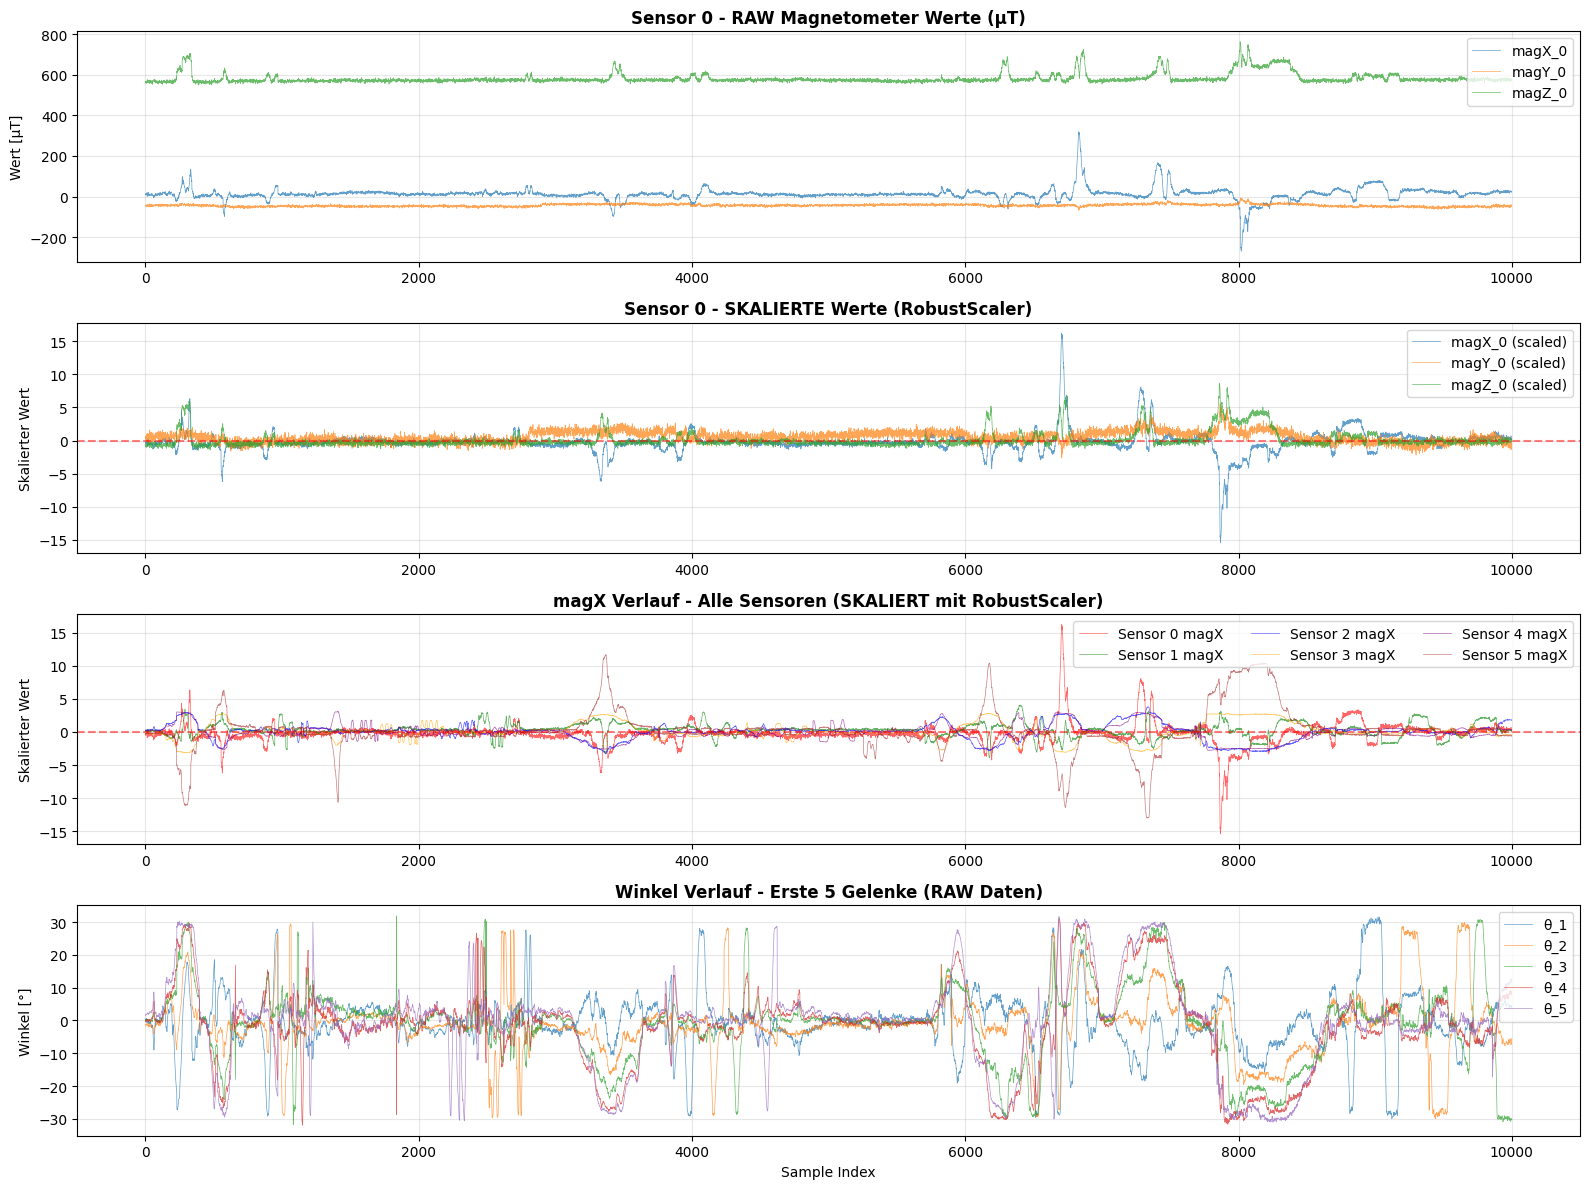


✅ Verlauf angezeigt


In [6]:
# ==================== ZEITVERLAUF: RAW vs SKALIERT vs WINKEL ====================
# Zeige die ersten 2000 Samples um den Verlauf zu sehen

sample_range = 10000  # Erste 2000 Samples
print(f"Zeige Verlauf der ersten {sample_range} Samples...")

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Plot 1: Rohwerte Sensor 0
ax = axes[0]
ax.plot(X_raw[:sample_range, 0], label='magX_0', alpha=0.7, linewidth=0.5)
ax.plot(X_raw[:sample_range, 1], label='magY_0', alpha=0.7, linewidth=0.5)
ax.plot(X_raw[:sample_range, 2], label='magZ_0', alpha=0.7, linewidth=0.5)
ax.set_title("Sensor 0 - RAW Magnetometer Werte (μT)", fontsize=12, fontweight='bold')
ax.set_ylabel("Wert [μT]")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: Skalierte Werte Sensor 0
ax = axes[1]
ax.plot(X_scaled[:sample_range, 0], label='magX_0 (scaled)', alpha=0.7, linewidth=0.5)
ax.plot(X_scaled[:sample_range, 1], label='magY_0 (scaled)', alpha=0.7, linewidth=0.5)
ax.plot(X_scaled[:sample_range, 2], label='magZ_0 (scaled)', alpha=0.7, linewidth=0.5)
ax.set_title("Sensor 0 - SKALIERTE Werte (RobustScaler)", fontsize=12, fontweight='bold')
ax.set_ylabel("Skalierter Wert")
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 3: Alle Sensoren (Skaliert) - Vergleich
ax = axes[2]
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']
features_per_sensor = len(feature_cols) // len(sensor_ids)
for sid in sensor_ids:
    idx = sid * features_per_sensor + 0  # magX für jeden Sensor
    ax.plot(X_scaled[:sample_range, idx], label=f'Sensor {sid} magX', alpha=0.6, linewidth=0.5, color=colors[sid])
ax.set_title("magX Verlauf - Alle Sensoren (SKALIERT mit RobustScaler)", fontsize=12, fontweight='bold')
ax.set_ylabel("Skalierter Wert")
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', ncol=3)
ax.grid(True, alpha=0.3)

# Plot 4: Winkel (Y_raw)
ax = axes[3]
for i in range(min(5, len(THETA_COLS))):  # Erste 5 Winkel
    ax.plot(Y_raw[:sample_range, i], label=f'θ_{i+1}', alpha=0.7, linewidth=0.5)
ax.set_title("Winkel Verlauf - Erste 5 Gelenke (RAW Daten)", fontsize=12, fontweight='bold')
ax.set_ylabel("Winkel [°]")
ax.set_xlabel("Sample Index")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Verlauf angezeigt")

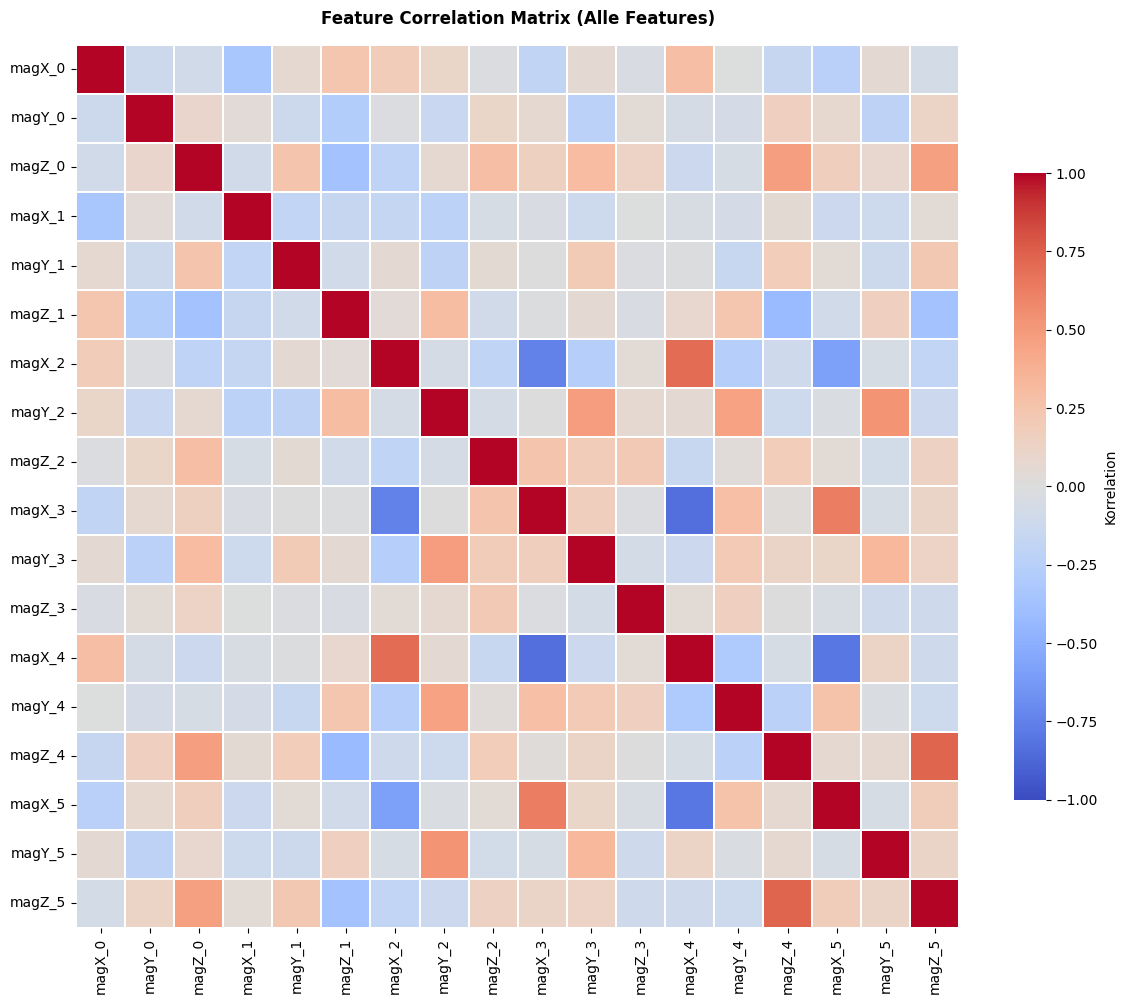

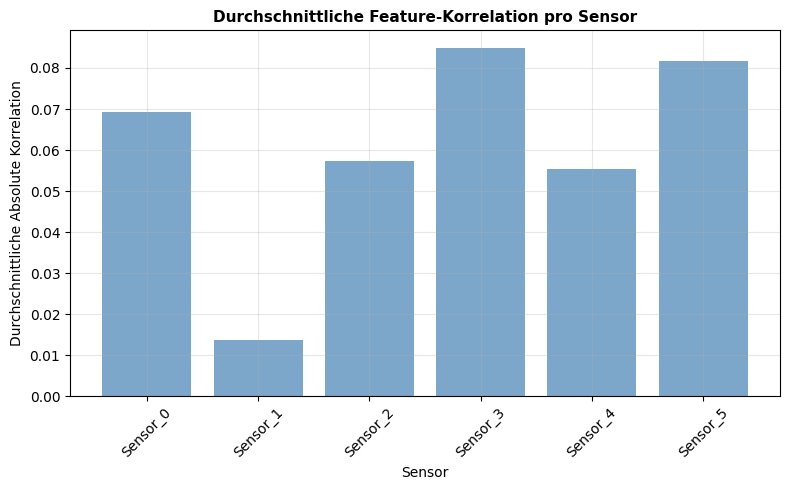


📊 Feature-Typen erkannt: ['magX', 'magZ', 'magY']


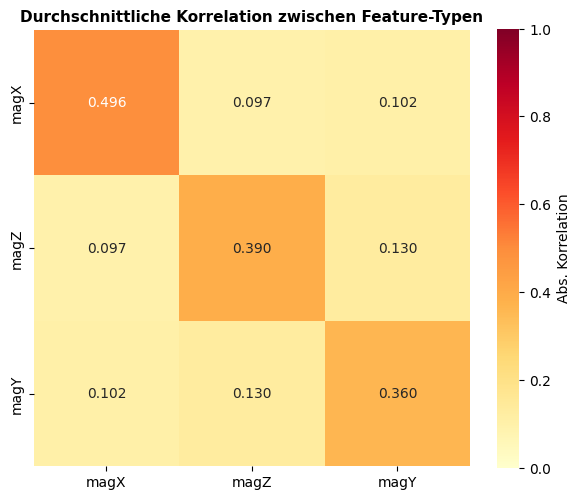


🔍 Stark korrelierte Feature-Paare (|r| > 0.9):
--------------------------------------------------------------------------------

✅ Gesamt: 0 stark korrelierte Feature-Paare gefunden


In [7]:
# ==================== FEATURE CORRELATION ANALYSIS ====================

import seaborn as sns

# Erstelle DataFrame mit Feature-Daten für Korrelationsanalyse
df_features = pd.DataFrame(X_clean, columns=feature_cols)

# Berechne Korrelationsmatrix
correlation_matrix = df_features.corr()

# Plot 1: Vollständige Korrelationsmatrix (alle Features)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.3,
            cbar_kws={"shrink": 0.7, "label": "Korrelation"})
plt.title("Feature Correlation Matrix (Alle Features)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Plot 2: Durchschnittliche Korrelation pro Sensor (aggregiert)
# Gruppiere Features nach Sensor-ID
sensor_correlation = {}
for sid in sensor_ids:
    sensor_features = [f for f in feature_cols if f.endswith(f'_{sid}')]
    if len(sensor_features) > 0:
        sensor_correlation[f'Sensor_{sid}'] = correlation_matrix[sensor_features].mean().mean()

plt.figure(figsize=(8, 5))
plt.bar(sensor_correlation.keys(), sensor_correlation.values(), color='steelblue', alpha=0.7)
plt.xlabel('Sensor')
plt.ylabel('Durchschnittliche Absolute Korrelation')
plt.title('Durchschnittliche Feature-Korrelation pro Sensor', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Korrelation zwischen verschiedenen Feature-Typen
# Gruppiere nach Feature-Typ (magX, magY, magZ, accMag)
feature_types = list(set([f.rsplit('_', 1)[0] for f in feature_cols]))
print(f"\n📊 Feature-Typen erkannt: {feature_types}")

# Berechne Inter-Type-Korrelation
inter_type_corr = pd.DataFrame(index=feature_types, columns=feature_types)

for ft1 in feature_types:
    for ft2 in feature_types:
        # Finde alle Spalten dieses Typs
        cols1 = [f for f in feature_cols if f.startswith(ft1 + '_')]
        cols2 = [f for f in feature_cols if f.startswith(ft2 + '_')]
        
        if len(cols1) > 0 and len(cols2) > 0:
            # Durchschnittliche Korrelation zwischen diesen Typen
            sub_corr = correlation_matrix.loc[cols1, cols2]
            inter_type_corr.loc[ft1, ft2] = sub_corr.abs().mean().mean()

inter_type_corr = inter_type_corr.astype(float)

plt.figure(figsize=(6, 5))
sns.heatmap(inter_type_corr, 
            annot=True, 
            fmt='.3f', 
            cmap='YlOrRd',
            vmin=0, vmax=1,
            square=True,
            cbar_kws={"label": "Abs. Korrelation"})
plt.title("Durchschnittliche Korrelation zwischen Feature-Typen", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistik: Stark korrelierte Feature-Paare finden
print("\n🔍 Stark korrelierte Feature-Paare (|r| > 0.9):")
print("-" * 80)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j], 
                corr_val
            ))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

for feat1, feat2, corr_val in high_corr_pairs[:20]:  # Zeige Top 20
    print(f"   {feat1:<20} <-> {feat2:<20} : {corr_val:6.3f}")

if len(high_corr_pairs) > 20:
    print(f"   ... und {len(high_corr_pairs)-20} weitere Paare")

print(f"\n✅ Gesamt: {len(high_corr_pairs)} stark korrelierte Feature-Paare gefunden")

In [8]:
# ==================== MODEL DEFINITION ====================

class RobotAngleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.1):
        super(RobotAngleLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# For FeedForward, use simpler model
class RobotAngleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.2):
        super(RobotAngleNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)  # 🔧 Dropout konfigurierbar
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# 🆕 Angle-Weighted MSE Loss: Große Winkel bekommen mehr Gewicht
class AngleWeightedMSE(nn.Module):
    """MSE Loss gewichtet nach Winkelmagnitude.
    
    Samples mit großen Winkeln (nahe ±1 in skaliertem Raum) bekommen
    höheres Gewicht, damit das Modell die Extreme besser lernt.
    
    weight_i = 1 + alpha * max(|y_target_i|)^2
    → Bei alpha=3: 0° → weight=1, ±30° → weight=4
    """
    def __init__(self, alpha=2.0):
        super().__init__()
        self.alpha = alpha
    
    def forward(self, y_pred, y_target):
        # Per-Sample Gewicht basierend auf max. absolutem Winkel über alle Gelenke
        max_abs_angle = torch.max(torch.abs(y_target), dim=1)[0]  # (batch,)
        weights = 1.0 + self.alpha * max_abs_angle ** 2            # (batch,)
        
        # Gewichteter MSE
        mse_per_sample = torch.mean((y_pred - y_target) ** 2, dim=1)  # (batch,)
        weighted_loss = torch.mean(weights * mse_per_sample)
        return weighted_loss

# Create model
input_dim = X_train.shape[2] if MODEL_TYPE == "LSTM" else X_train.shape[1]
output_dim = len(THETA_COLS)

if MODEL_TYPE == "LSTM":
    model = RobotAngleLSTM(input_dim, HIDDEN_SIZE, NUM_LSTM_LAYERS, output_dim, DROPOUT_RATE).to(device)
else:
    model = RobotAngleNet(input_dim, HIDDEN_SIZE, output_dim, DROPOUT_RATE).to(device)

# 🎯 Weighted Loss: Große Winkel zählen mehr (alpha=3 → 4x Gewicht bei ±30°)
ANGLE_WEIGHT_ALPHA = 2.5
criterion = AngleWeightedMSE(alpha=ANGLE_WEIGHT_ALPHA)
print(f"\n⚖️  Loss: AngleWeightedMSE (alpha={ANGLE_WEIGHT_ALPHA})")
print(f"   Gewicht bei 0°: 1.0x | bei ±15°: ~2.0x | bei ±30°: ~4.0x")

# 🆕 L2-Regularisierung via weight_decay
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"\nModel created:")
print(f"  Input: {input_dim} features")
print(f"  Output: {output_dim} joints")
print(f"  Total params: {sum(p.numel() for p in model.parameters())}")
print(f"  Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Dropout: {DROPOUT_RATE}")


⚖️  Loss: AngleWeightedMSE (alpha=2.5)
   Gewicht bei 0°: 1.0x | bei ±15°: ~2.0x | bei ±30°: ~4.0x

Model created:
  Input: 18 features
  Output: 13 joints
  Total params: 55629
  Optimizer: Adam (lr=0.001, weight_decay=0.0001)
  Dropout: 0.3


In [9]:
# ==================== TRAINING ====================

import copy

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0  # 🆕 Early Stopping Counter

print(f"Starting training for {EPOCHS} epochs...")
print(f"Early Stopping: Patience = {EARLY_STOPPING_PATIENCE} epochs\n")

for epoch in range(EPOCHS):
    # Training
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # Validation (auf Validation-Set, NICHT Test-Set!)
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_batch_losses.append(loss.item())
    
    val_loss = np.mean(val_batch_losses)
    val_losses.append(val_loss)
    
    # 🆕 Early Stopping: Speichere bestes Modell und verfolge Geduld
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0  # Zurücksetzen wenn Verbesserung
        improved_marker = "✓"
    else:
        patience_counter += 1
        improved_marker = ""
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} {improved_marker}")
    
    # 🆕 Early Stopping: Abbruch wenn kein Fortschritt mehr
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n⏹️  Early Stopping nach Epoch {epoch+1}!")
        print(f"   Kein Fortschritt für {EARLY_STOPPING_PATIENCE} Epochen. Beste Val Loss: {best_val_loss:.5f}")
        break

print(f"\n✅ Training complete. Best Val Loss: {best_val_loss:.5f}")

# Load best model
model.load_state_dict(best_model_wts)

Starting training for 150 epochs...
Early Stopping: Patience = 40 epochs

Epoch  10/150 | Train Loss: 0.02907 | Val Loss: 0.02655 ✓
Epoch  20/150 | Train Loss: 0.02271 | Val Loss: 0.02177 ✓
Epoch  30/150 | Train Loss: 0.02010 | Val Loss: 0.01957 ✓
Epoch  40/150 | Train Loss: 0.01889 | Val Loss: 0.01876 
Epoch  50/150 | Train Loss: 0.01793 | Val Loss: 0.01782 
Epoch  60/150 | Train Loss: 0.01754 | Val Loss: 0.01692 
Epoch  70/150 | Train Loss: 0.01699 | Val Loss: 0.01733 
Epoch  80/150 | Train Loss: 0.01756 | Val Loss: 0.01612 
Epoch  90/150 | Train Loss: 0.01697 | Val Loss: 0.01668 
Epoch 100/150 | Train Loss: 0.01663 | Val Loss: 0.01527 
Epoch 110/150 | Train Loss: 0.01667 | Val Loss: 0.01551 
Epoch 120/150 | Train Loss: 0.01595 | Val Loss: 0.01662 
Epoch 130/150 | Train Loss: 0.01631 | Val Loss: 0.01650 
Epoch 140/150 | Train Loss: 0.01546 | Val Loss: 0.01523 
Epoch 150/150 | Train Loss: 0.01661 | Val Loss: 0.01661 

✅ Training complete. Best Val Loss: 0.01493


<All keys matched successfully>

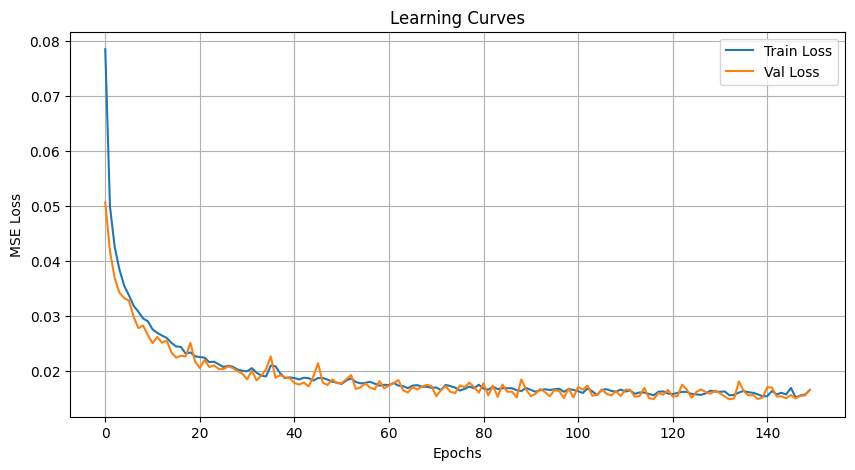


📊 Per-Joint RMSE (auf Test-Run):
   θ1: RMSE=3.45° | MAE=2.22°
   θ2: RMSE=3.33° | MAE=2.08°
   θ3: RMSE=3.39° | MAE=2.31°
   θ4: RMSE=3.03° | MAE=2.00°
   θ5: RMSE=2.88° | MAE=1.98°


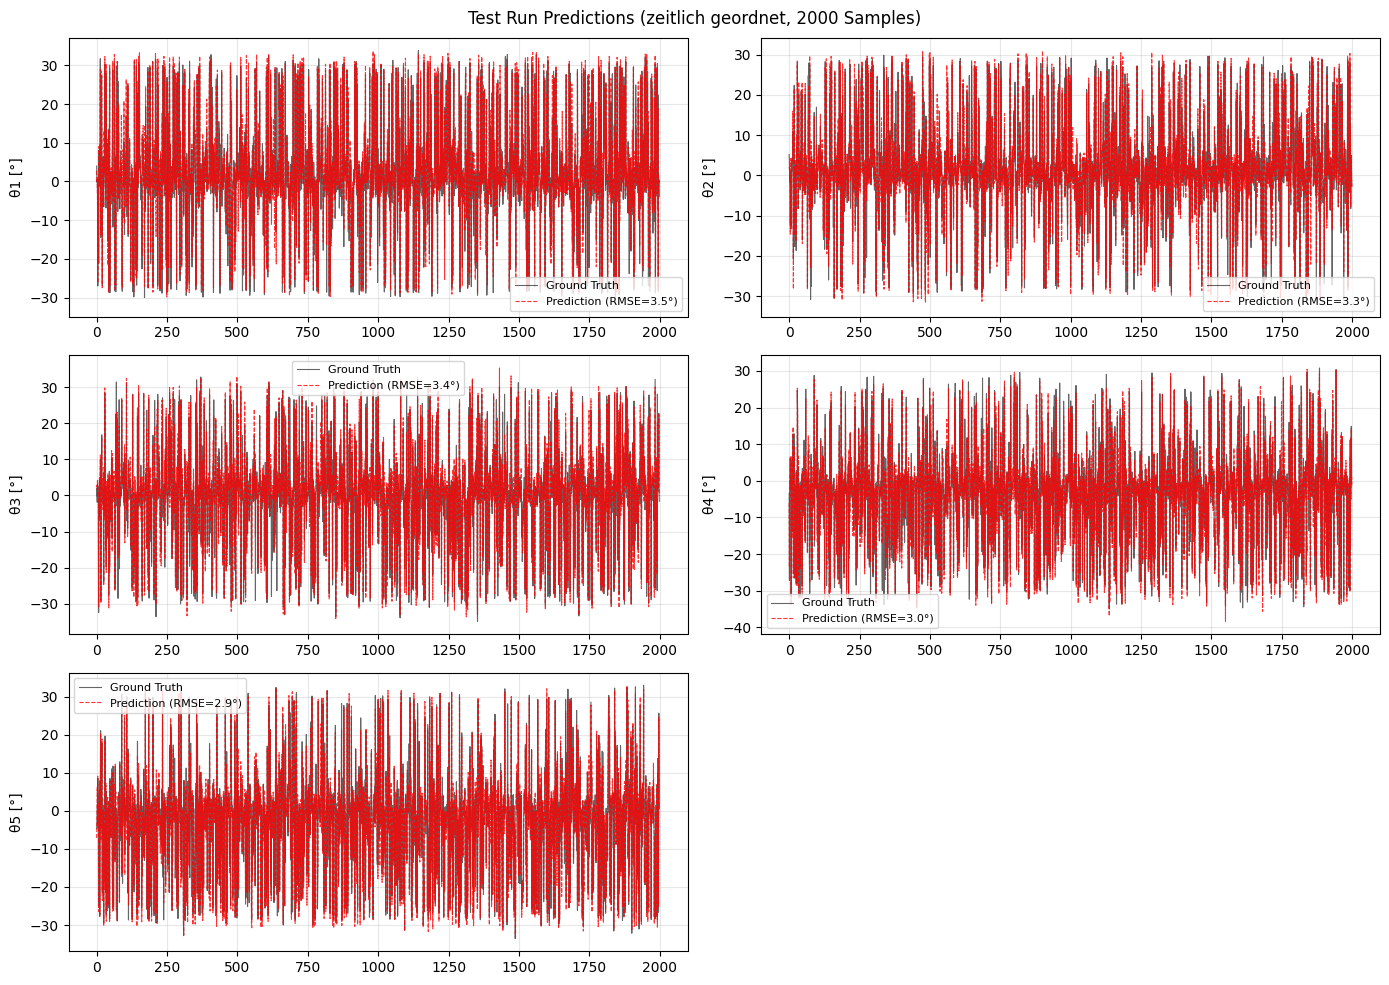

In [10]:
# ==================== EVALUATE ====================

model.eval()
y_pred_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        y_pred_scaled.append(outputs.cpu().numpy())

y_pred_scaled = np.concatenate(y_pred_scaled, axis=0)

# Rücktransformation in Grad
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_deg = scaler_y.inverse_transform(y_test)

# Plot learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Learning Curves")
plt.grid(True)
plt.show()

# Plot predictions vs ground truth (first 5 joints)
# Test-Daten sind jetzt zeitlich geordnet (ganzer Run) → sinnvoller Verlauf
limit = min(2000, len(y_pred))
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

# RMSE pro Gelenk berechnen
print(f"\n📊 Per-Joint RMSE (auf Test-Run):")
for i in range(min(5, len(THETA_COLS))):
    rmse = np.sqrt(np.mean((y_pred[:, i] - y_test_deg[:, i])**2))
    mae = np.mean(np.abs(y_pred[:, i] - y_test_deg[:, i]))
    print(f"   θ{i+1}: RMSE={rmse:.2f}° | MAE={mae:.2f}°")
    
    ax = axes[i]
    ax.plot(y_test_deg[:limit, i], label="Ground Truth", color="black", alpha=0.6, linewidth=0.8)
    ax.plot(y_pred[:limit, i], label=f"Prediction (RMSE={rmse:.1f}°)", color="red", linestyle="--", alpha=0.8, linewidth=0.8)
    ax.set_ylabel(f"θ{i+1} [°]")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle(f"Test Run Predictions (zeitlich geordnet, {limit} Samples)")
plt.tight_layout()
plt.show()

In [ ]:
# ==================== SAVE MODEL ====================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model_type_short = "LSTM" if MODEL_TYPE == "LSTM" else "FF"
run_name = f"{timestamp}_{model_type_short}_h{HIDDEN_SIZE}_s{len(sensor_ids)}_d{DROPOUT_RATE}"
save_path = os.path.join("trained_models", run_name)
os.makedirs(save_path, exist_ok=True)

print(f"\n💾 Saving model to {save_path}")

# Save model weights
torch.save(model.state_dict(), os.path.join(save_path, "model.pth"))

# Save scalers
joblib.dump(scaler_x_list, os.path.join(save_path, "scaler_x.pkl"))  # Liste von Scalern (pro Sensor)
joblib.dump(scaler_y, os.path.join(save_path, "scaler_y.pkl"))

# Save config
config = {
    "timestamp": timestamp,
    "model_type": MODEL_TYPE,
    "input_size": input_dim,
    "output_size": output_dim,
    "output_dim": output_dim,
    "hidden_size": HIDDEN_SIZE,
    "num_lstm_layers": NUM_LSTM_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "weight_decay": WEIGHT_DECAY,  # 🆕 L2-Regularisierung
    "window_size": WINDOW_SIZE,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "final_val_loss": float(best_val_loss),
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,  # 🆕 Early Stopping Info
    "sensor_features": feature_cols,
    "output_columns": THETA_COLS
}

with open(os.path.join(save_path, "model_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print(f"✅ Model saved successfully!")
print(f"   Path: {save_path}")
print(f"   Sensoren: {len(sensor_ids)} ({len(feature_cols)} Features total)")
print(f"   Regularisierung: Dropout={DROPOUT_RATE}, L2={WEIGHT_DECAY}")
print(f"   Early Stopping: {EARLY_STOPPING_PATIENCE} epochs patience")


💾 Saving model to trained_models\2026-02-20_14-36-50_LSTM_h64_s6_d0.3
✅ Model saved successfully!
   Path: trained_models\2026-02-20_14-36-50_LSTM_h64_s6_d0.3
   Sensoren: 6 (18 Features total)
   Regularisierung: Dropout=0.3, L2=0.0001
   Early Stopping: 40 epochs patience


: 